# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [1]:
#! pip install mne

#nothing

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS, FREQ_BANDS

# Define subjects for multi-subject analysis
# Note: Only subject 5 data files are available in the dataset
SUBJECTS = [5]

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [4]:
CONDITION  = "BLA"
SUBJECT_ID = 5
CHANNELS   = "BLA"   # T7, T8, TP7, TP8

# Data path (resolved inside utils): <project>/dataset/BLA/binepochs filtered ICArej BLAAvgBOS5.set
epochs = load_eeg_data(CONDITION, SUBJECT_ID, channels=CHANNELS)

data   = epochs.get_data()   # (n_trials, n_channels, n_times)  — in Volts (MNE default)
data   = data * 1e6           # convert to µV
times  = epochs.times        # in seconds
ch_names = epochs.ch_names
sfreq  = epochs.info['sfreq']

n_trials, n_channels, n_times = data.shape

print(f"Condition     : {CONDITION}  |  Subject: {SUBJECT_ID}")
print(f"Channels      : {ch_names}")
print(f"Trials        : {n_trials}")
print(f"Time window   : {times[0]*1000:.0f} ms  to  {times[-1]*1000:.0f} ms")
print(f"Sampling rate : {sfreq} Hz")
print(f"Data shape    : {data.shape}  (trials × channels × times)")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Condition     : BLA  |  Subject: 5
Channels      : ['T7', 'T8', 'TP7', 'TP8']
Trials        : 60
Time window   : -500 ms  to  2998 ms
Sampling rate : 512.0 Hz
Data shape    : (60, 4, 1792)  (trials × channels × times)


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 2. Baseline Correction  (−200 ms to 0 ms, mean subtraction)

In [7]:
BASELINE_TMIN = -0.200   # seconds
BASELINE_TMAX =  0.000

baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
print(f"Baseline samples : {baseline_mask.sum()}  "
      f"({times[baseline_mask][0]*1000:.0f} ms to {times[baseline_mask][-1]*1000:.0f} ms)")

# Mean per trial × channel over the baseline window
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (trials, channels, 1)

# Subtract from every time point
data_bc = data - baseline_mean   # (trials, channels, times)

print("Baseline correction done — data_bc shape:", data_bc.shape)

Baseline samples : 103  (-199 ms to 0 ms)
Baseline correction done — data_bc shape: (60, 4, 1792)


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

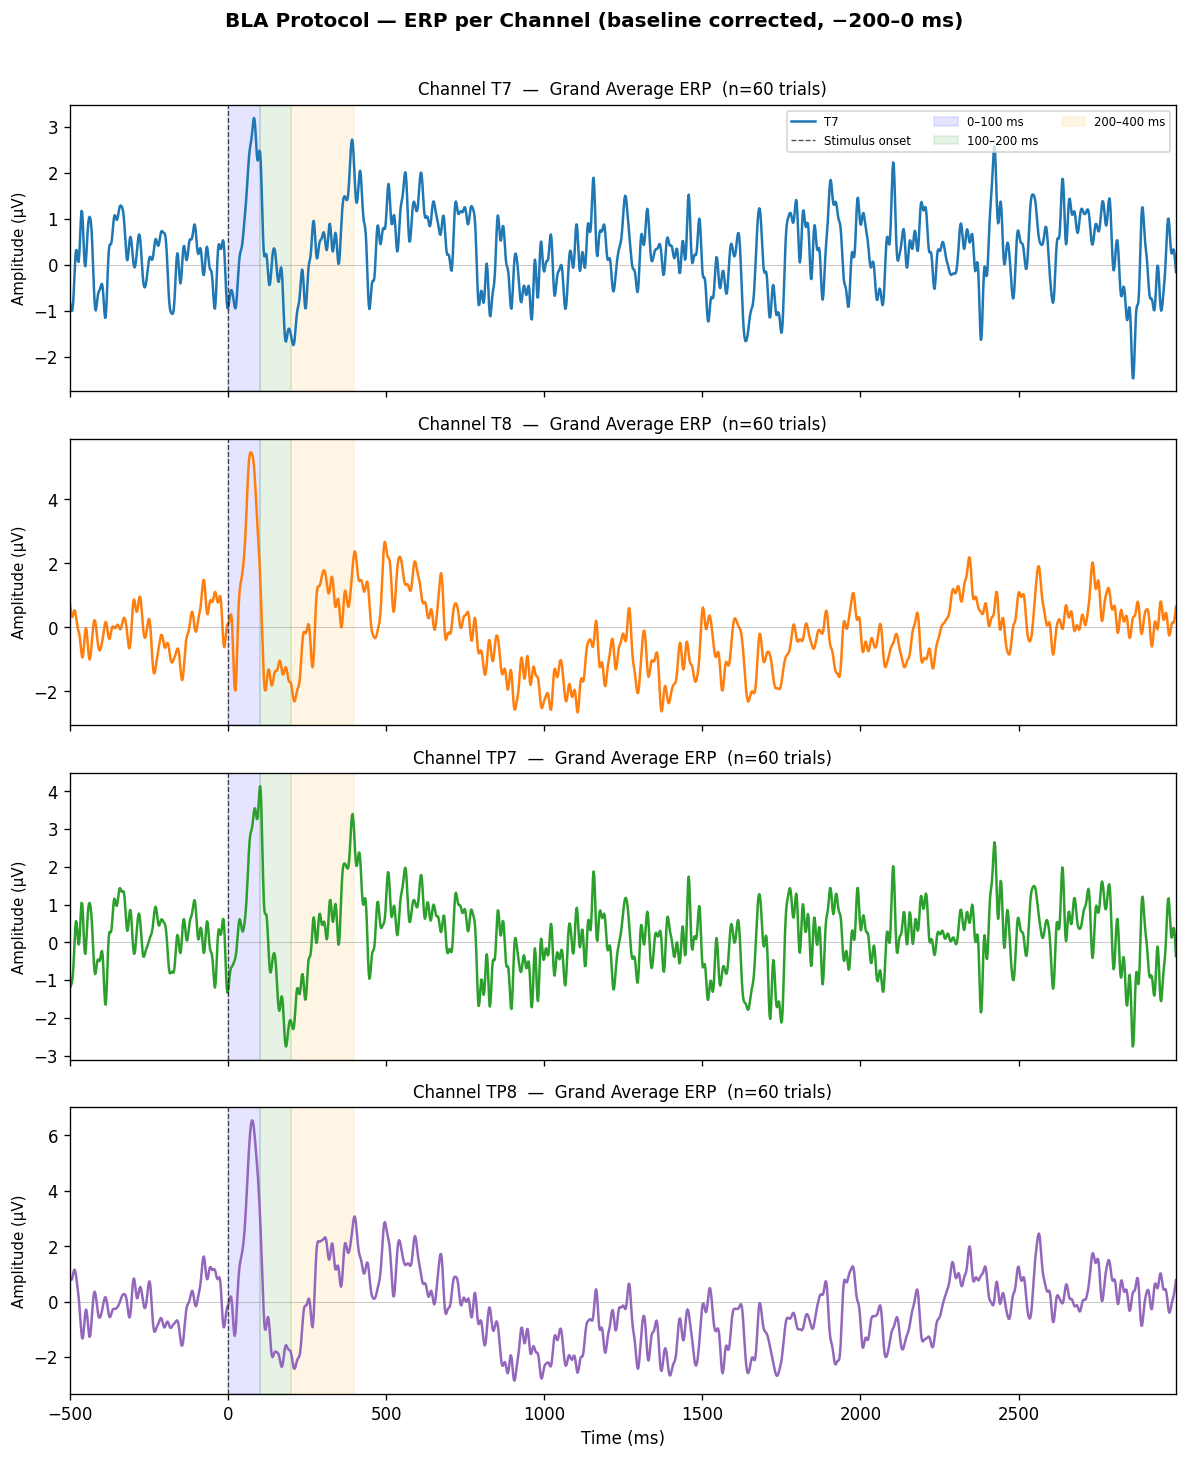

Figure saved: erp_BLA_per_channel.png


In [8]:
erp = data_bc.mean(axis=0)   # (n_channels, n_times)  — grand average ERP
times_ms = times * 1000      # convert to ms for plotting

fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)
if n_channels == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.4, n_channels))

for i, (ax, ch) in enumerate(zip(axes, ch_names)):
    ax.plot(times_ms, erp[i], color=colors[i], linewidth=1.5, label=ch)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7, label='Stimulus onset')
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Shade feature windows
    ax.axvspan(0, 100,   alpha=0.10, color='blue',   label='0–100 ms')
    ax.axvspan(100, 200, alpha=0.10, color='green',  label='100–200 ms')
    ax.axvspan(200, 400, alpha=0.10, color='orange', label='200–400 ms')

    ax.set_ylabel('Amplitude (µV)', fontsize=9)
    ax.set_title(f'Channel {ch}  —  Grand Average ERP  (n={n_trials} trials)', fontsize=10)
    ax.set_xlim(times_ms[0], times_ms[-1])

    if i == 0:
        ax.legend(loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('Time (ms)', fontsize=10)
fig.suptitle(f'BLA Protocol — ERP per Channel (baseline corrected, −200–0 ms)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('erp_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: erp_BLA_per_channel.png")

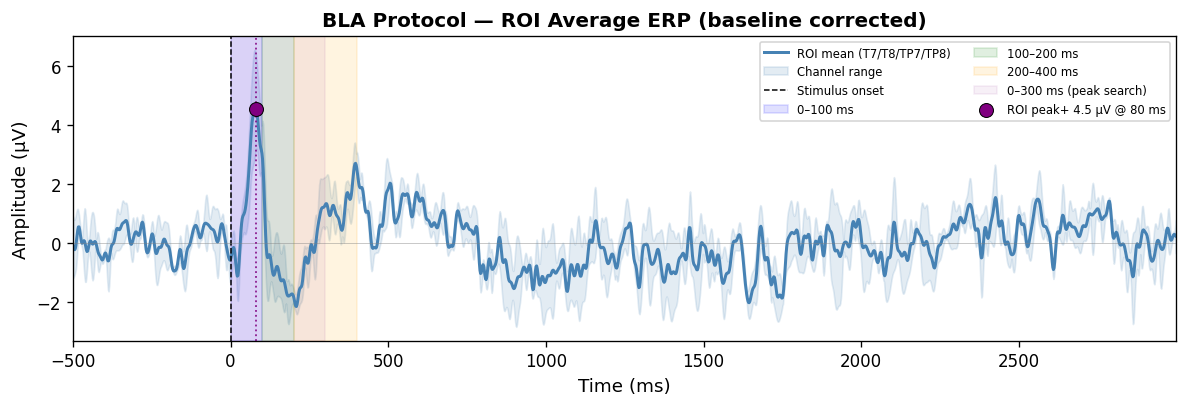

In [9]:
# --- ROI average ERP (mean across all BLA channels) ---
erp_roi = erp.mean(axis=0)   # (n_times,)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(times_ms, erp_roi, color='steelblue', linewidth=1.8, label='ROI mean (T7/T8/TP7/TP8)')
ax.fill_between(times_ms, erp.min(axis=0), erp.max(axis=0),
                color='steelblue', alpha=0.15, label='Channel range')
ax.axvline(0, color='k', linestyle='--', linewidth=0.9, label='Stimulus onset')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvspan(0, 100,   alpha=0.12, color='blue',   label='0–100 ms')
ax.axvspan(100, 200, alpha=0.12, color='green',  label='100–200 ms')
ax.axvspan(200, 400, alpha=0.12, color='orange', label='200–400 ms')
ax.axvspan(0, 300, alpha=0.06, color='purple', label='0–300 ms (peak search)')

# Grand-average ROI: peak positive & latency in 0–300 ms (same definition as trial features)
_pk_mask = (times_ms >= 0) & (times_ms <= 300)
_t = times_ms[_pk_mask]
_v = erp_roi[_pk_mask]
_i = int(np.argmax(_v))
_lat, _amp = _t[_i], _v[_i]
ax.scatter([_lat], [_amp], color='purple', s=70, zorder=6, edgecolors='k', linewidths=0.6,
           label=f'ROI peak+ {_amp:.1f} µV @ {_lat:.0f} ms')
ax.axvline(_lat, color='purple', linestyle=':', linewidth=1.1, alpha=0.85)

ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (µV)', fontsize=11)
ax.set_title('BLA Protocol — ROI Average ERP (baseline corrected)', fontsize=12, fontweight='bold')
ax.set_xlim(times_ms[0], times_ms[-1])
ax.legend(loc='upper right', fontsize=7, ncol=2)
fig.tight_layout()
plt.savefig('erp_BLA_roi_average.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [5]:
# Time masks for each feature window
mask_0_100   = (times >= 0.000) & (times <= 0.100)
mask_100_200 = (times >= 0.100) & (times <= 0.200)
mask_200_400 = (times >= 0.200) & (times <= 0.400)
mask_0_300   = (times >= 0.000) & (times <= 0.300)   # peak search window

print("Window sample counts:")
print(f"  0–100 ms  : {mask_0_100.sum()} samples")
print(f"  100–200 ms: {mask_100_200.sum()} samples")
print(f"  200–400 ms: {mask_200_400.sum()} samples")
print(f"  0–300 ms  : {mask_0_300.sum()} samples (peak amp / latency)")

# Feature arrays: (n_trials, n_channels) — mean amplitude windows
feat_0_100   = data_bc[:, :, mask_0_100].mean(axis=-1)
feat_100_200 = data_bc[:, :, mask_100_200].mean(axis=-1)
feat_200_400 = data_bc[:, :, mask_200_400].mean(axis=-1)

# Peak positive amplitude & latency in 0–300 ms (per trial × channel)
times_0_300 = times[mask_0_300]
win_0_300 = data_bc[:, :, mask_0_300]   # (trials, ch, samples)
peak_ix = win_0_300.argmax(axis=-1)   # index of maximum µV in window
feat_peak_amp_0_300 = np.take_along_axis(win_0_300, peak_ix[..., None], axis=-1).squeeze(-1)
feat_peak_lat_0_300_ms = times_0_300[peak_ix] * 1000.0   # seconds → ms

# ROI average across channels: (n_trials,)
roi_0_100   = feat_0_100.mean(axis=1)
roi_100_200 = feat_100_200.mean(axis=1)
roi_200_400 = feat_200_400.mean(axis=1)
roi_peak_amp_0_300 = feat_peak_amp_0_300.mean(axis=1)
roi_peak_lat_0_300 = feat_peak_lat_0_300_ms.mean(axis=1)

trial_idx = np.arange(1, n_trials + 1)

# Collect into a DataFrame for easy inspection
rows = []
for t in range(n_trials):
    for c, ch in enumerate(ch_names):
        rows.append({
            'trial': t + 1,
            'channel': ch,
            'amp_0_100':   feat_0_100[t, c],
            'amp_100_200': feat_100_200[t, c],
            'amp_200_400': feat_200_400[t, c],
            'peak_pos_amp_0_300_uv': feat_peak_amp_0_300[t, c],
            'peak_lat_0_300_ms':     feat_peak_lat_0_300_ms[t, c],
        })
features_df = pd.DataFrame(rows)
print("\nFeature DataFrame (first 8 rows):")
features_df.head(8)


Window sample counts:
  0–100 ms  : 52 samples
  100–200 ms: 51 samples
  200–400 ms: 102 samples
  0–300 ms  : 154 samples (peak amp / latency)


NameError: name 'data_bc' is not defined

In [6]:
# Basic statistics across trials (ROI average)
print("ROI-averaged feature statistics across trials:")
summary = pd.DataFrame({
    '0–100 ms':   roi_0_100,
    '100–200 ms': roi_100_200,
    '200–400 ms': roi_200_400,
    'Peak+ 0–300 µV': roi_peak_amp_0_300,
    'Peak lat 0–300 ms': roi_peak_lat_0_300,
})
summary.describe().round(4)


ROI-averaged feature statistics across trials:


NameError: name 'roi_0_100' is not defined

## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

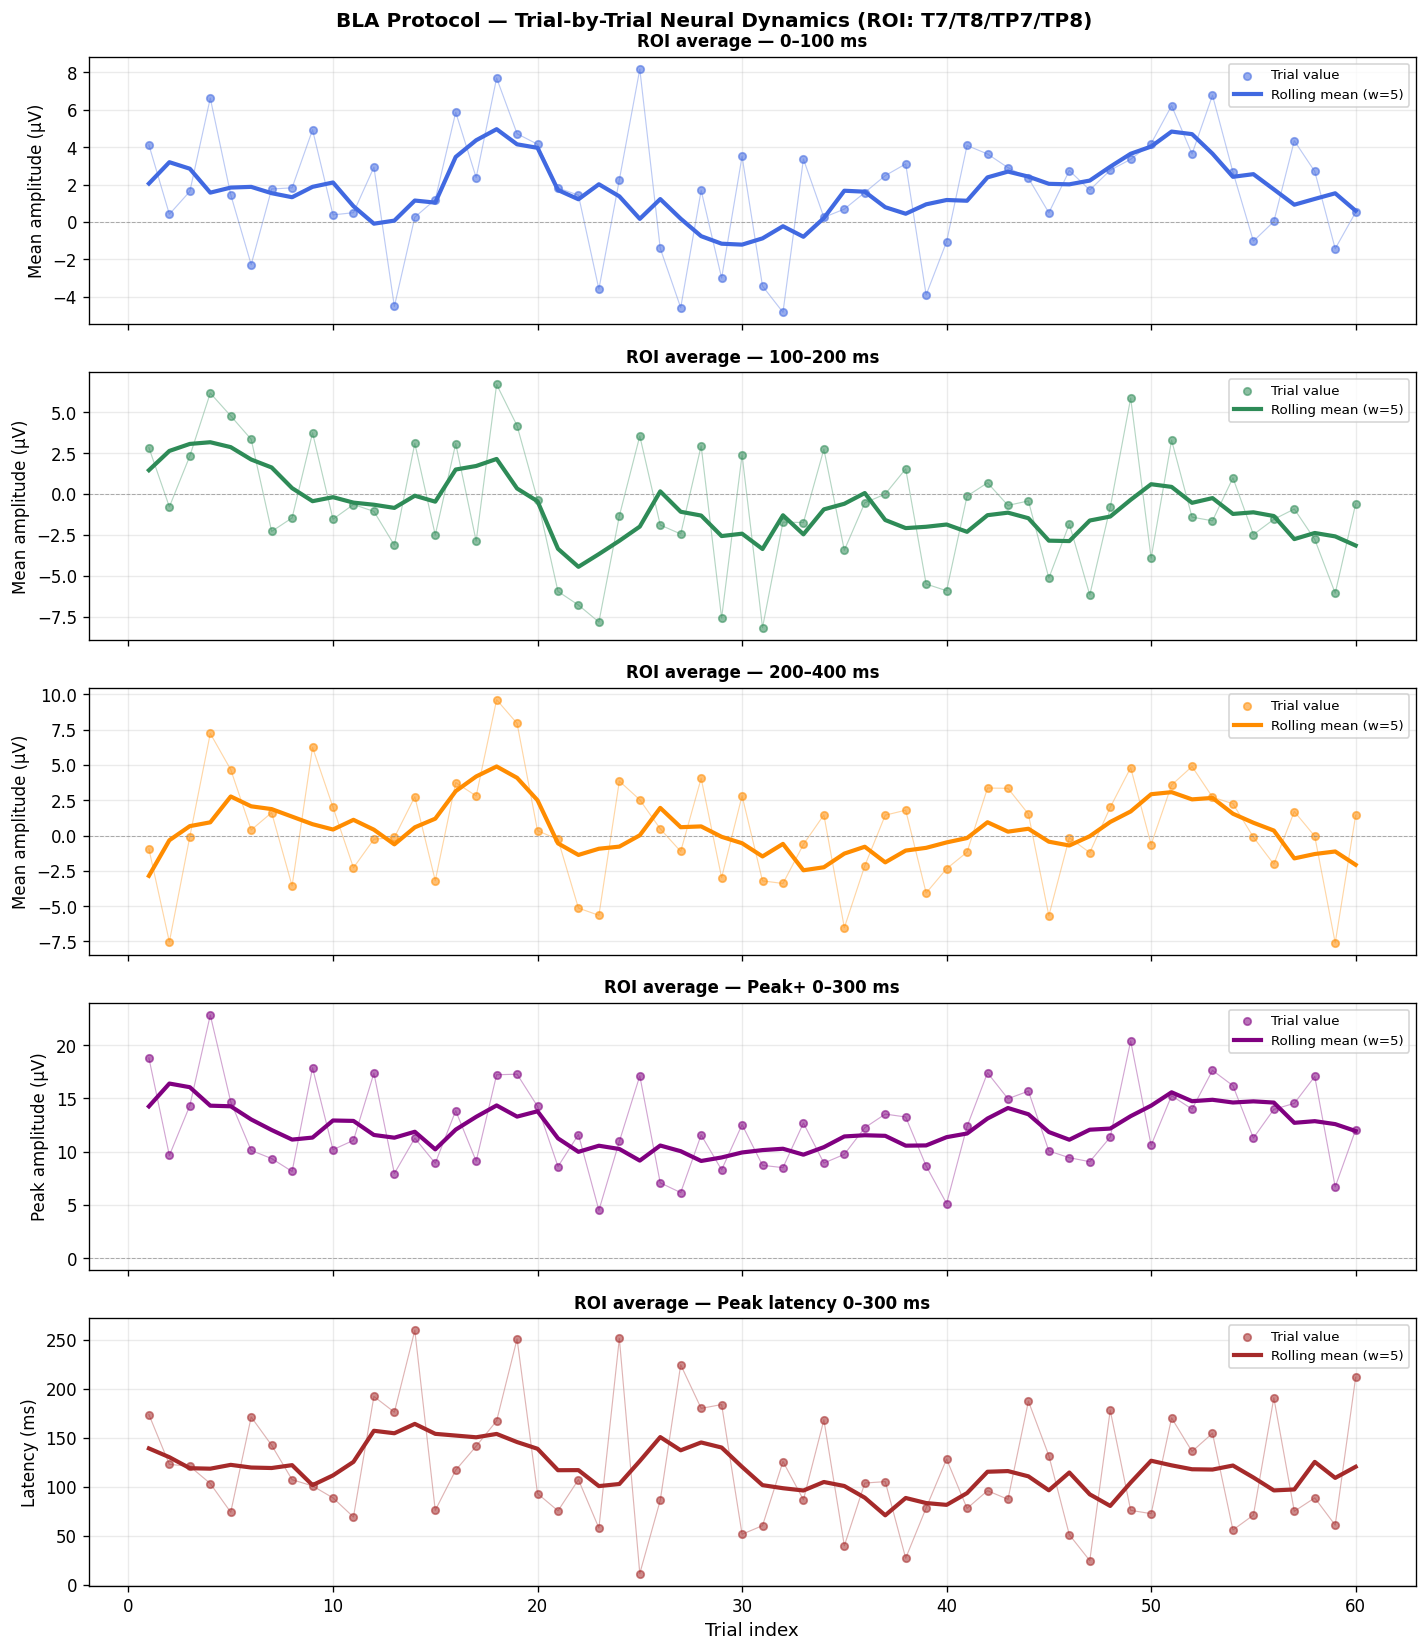

Figure saved: trial_dynamics_BLA_roi.png


In [12]:
ROLLING_WINDOW = 5   # trials in the moving average

windows = [
    ('0–100 ms',   roi_0_100,   'royalblue',   'Mean amplitude (µV)'),
    ('100–200 ms', roi_100_200, 'seagreen',    'Mean amplitude (µV)'),
    ('200–400 ms', roi_200_400, 'darkorange',  'Mean amplitude (µV)'),
    ('Peak+ 0–300 ms', roi_peak_amp_0_300, 'purple', 'Peak amplitude (µV)'),
    ('Peak latency 0–300 ms', roi_peak_lat_0_300, 'brown', 'Latency (ms)'),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, (label, values, color, ylab) in zip(axes, windows):
    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    s = pd.Series(values)
    rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})')

    if not label.startswith('Peak latency'):
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(f'ROI average — {label}', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Trial-by-Trial Neural Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_roi.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_roi.png")


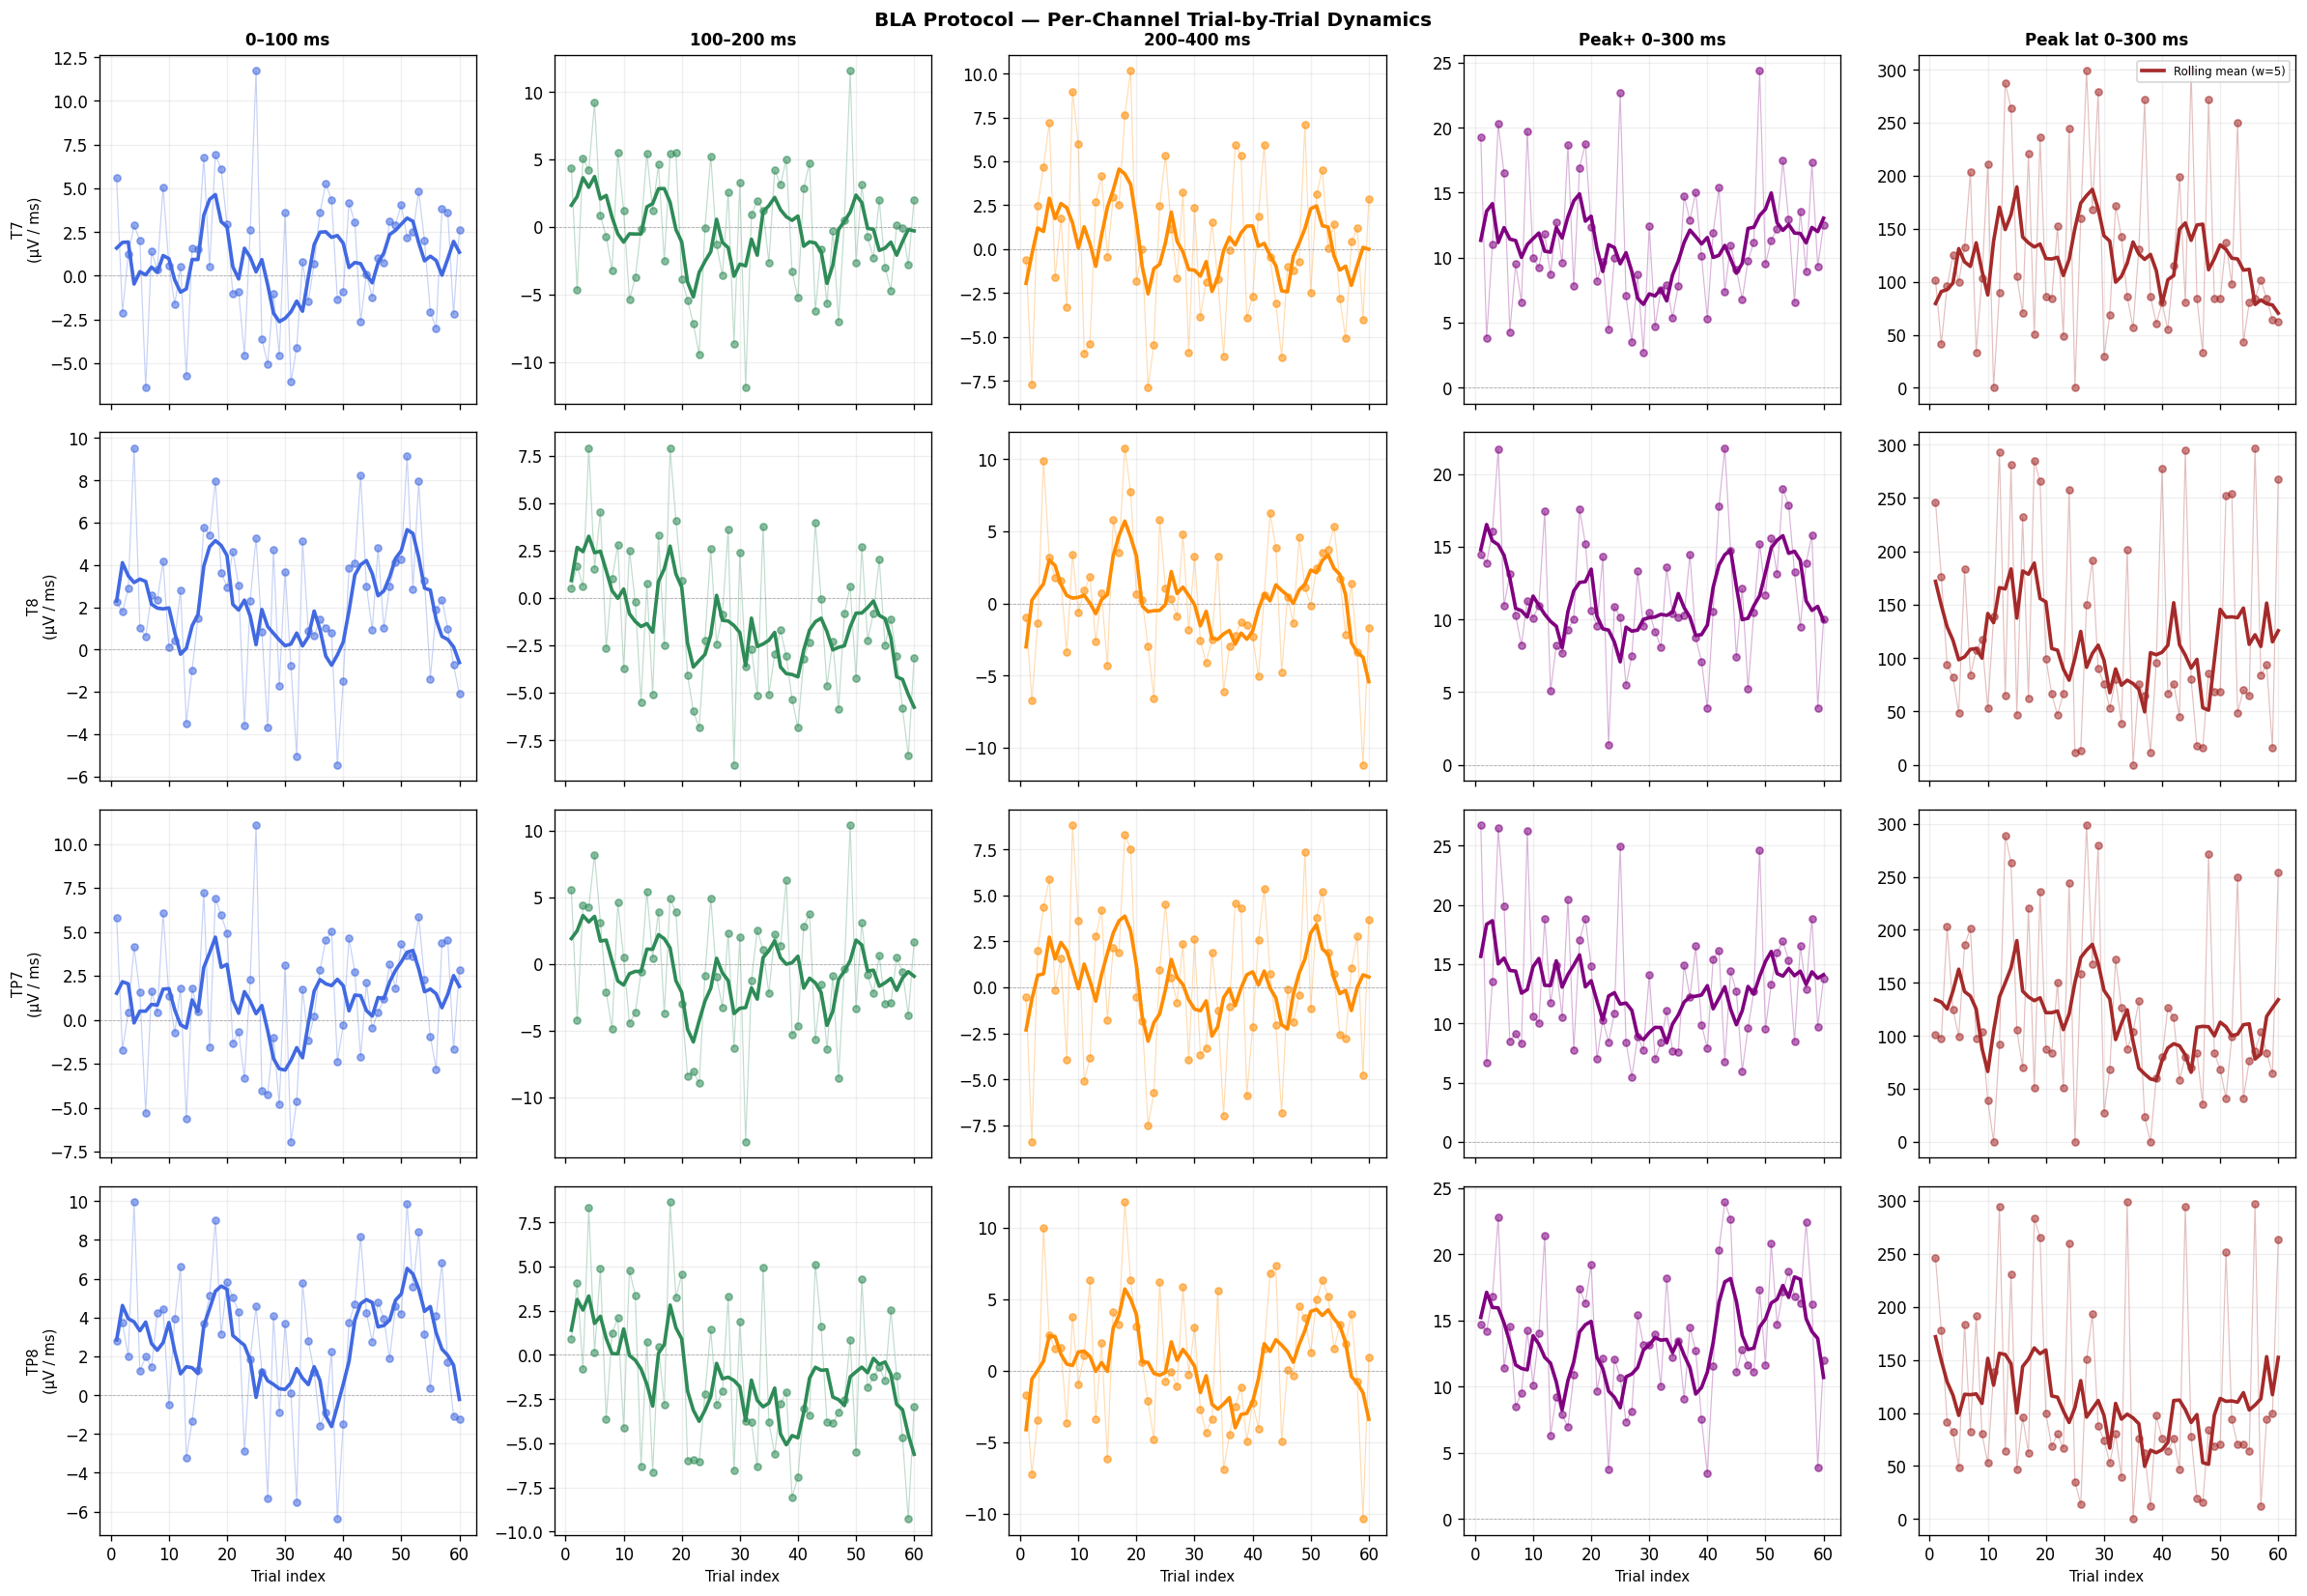

Figure saved: trial_dynamics_BLA_per_channel.png


In [13]:
# --- Per-channel trial-by-trial dynamics ---

feat_arrays = [
    ('0–100 ms',   feat_0_100,   'royalblue'),
    ('100–200 ms', feat_100_200, 'seagreen'),
    ('200–400 ms', feat_200_400, 'darkorange'),
    ('Peak+ 0–300 ms', feat_peak_amp_0_300, 'purple'),
    ('Peak lat 0–300 ms', feat_peak_lat_0_300_ms, 'brown'),
]

fig, axes = plt.subplots(n_channels, 5,
                          figsize=(20, 3.5 * n_channels),
                          sharex=True)

if n_channels == 1:
    axes = axes[np.newaxis, :]

for row, ch in enumerate(ch_names):
    for col, (label, feat_arr, color) in enumerate(feat_arrays):
        ax = axes[row, col]
        values = feat_arr[:, row]

        ax.scatter(trial_idx, values, color=color, s=18, alpha=0.55, zorder=2)
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.30, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.2, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        if col != 4:
            ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ch}\n(µV / ms)', fontsize=9)
        if row == n_channels - 1:
            ax.set_xlabel('Trial index', fontsize=9)

        if row == 0 and col == 4:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle('BLA Protocol — Per-Channel Trial-by-Trial Dynamics',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_per_channel.png")


## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Feature windows | 0–100, 100–200, 200–400 ms (mean µV); 0–300 ms (peak µV + peak latency ms) |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)


## 6. Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLA trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (14 subjects)

In [15]:
# Test the function import
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Define subjects to analyze
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]  # All available BLA subjects
CONDITION = "BLA"
CHANNELS = "BLA"
ROLLING_WINDOW = 5  # trials in the moving average

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")

Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [16]:
# Compute frequency power for each subject
all_power_dfs = {}
all_power_pivots = {}
all_psds_dicts = {}

for subject_id in SUBJECTS:
    print(f"\n--- Processing Subject {subject_id} ---")

    # Load data for this subject
    epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)

    # Compute frequency power
    power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

    # Pivot to see power per band per trial (averaged across channels)
    power_pivot = power_df.groupby(['trial', 'band'])['power'].mean().unstack()

    # Store results
    all_power_dfs[subject_id] = power_df
    all_power_pivots[subject_id] = power_pivot
    all_psds_dicts[subject_id] = psds_dict

    print(f"Subject {subject_id}: {len(power_pivot)} trials analyzed")

# Display results for first subject as example
subject_id = SUBJECTS[0]
print(f"\n--- Results for Subject {subject_id} (example) ---")
print("Frequency power DataFrame (first 10 rows):")
all_power_dfs[subject_id].head(10)

print(f"\nPower per band per trial (ROI average) - first 10 trials:")
all_power_pivots[subject_id].head(10)


--- Processing Subject 2 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 2: 60 trials analyzed

--- Processing Subject 3 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 3: 60 trials analyzed

--- Processing Subject 5 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 5: 60 trials analyzed

--- Processing Subject 6 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 6: 60 trials analyzed

--- Processing Subject 7 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 7: 60 trials analyzed

--- Processing Subject 8 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 8: 60 trials analyzed

--- Processing Subject 9 ---


...

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 12: 60 trials analyzed

--- Processing Subject 13 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 13: 60 trials analyzed

--- Processing Subject 15 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 15: 60 trials analyzed

--- Processing Subject 16 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 16: 60 trials analyzed

--- Processing Subject 17 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 17: 60 trials analyzed

--- Results for Subject 2 (example) ---
Frequency power DataFrame (first 10 rows):

Power per band per trial (ROI average) - first 10 trials:


band,above_gamma,alpha,below_delta,beta,delta,gamma,theta
trial,,,,,,,
0,NaN,2.179041e-12,NaN,3.957751e-12,3.770583e-12,1.919517e-12,2.954823e-12
1,NaN,1.506729e-12,NaN,3.817573e-12,2.965146e-12,2.395539e-12,2.455427e-12
2,NaN,1.678608e-12,NaN,3.524275e-12,2.831944e-12,2.465148e-12,3.725387e-12
3,NaN,1.600058e-12,NaN,3.669474e-12,3.452341e-12,2.733803e-12,3.263675e-12
4,NaN,1.923995e-12,NaN,4.921076e-12,4.542648e-12,2.576766e-12,3.549005e-12
5,NaN,2.516633e-12,NaN,4.308665e-12,3.752338e-12,2.326660e-12,3.373842e-12
6,NaN,1.858633e-12,NaN,4.269266e-12,4.343885e-12,2.333538e-12,3.044574e-12
7,NaN,1.571779e-12,NaN,3.540283e-12,4.004514e-12,2.326368e-12,3.223507e-12
8,NaN,2.047844e-12,NaN,4.601067e-12,3.127235e-12,2.760212e-12,3.242787e-12


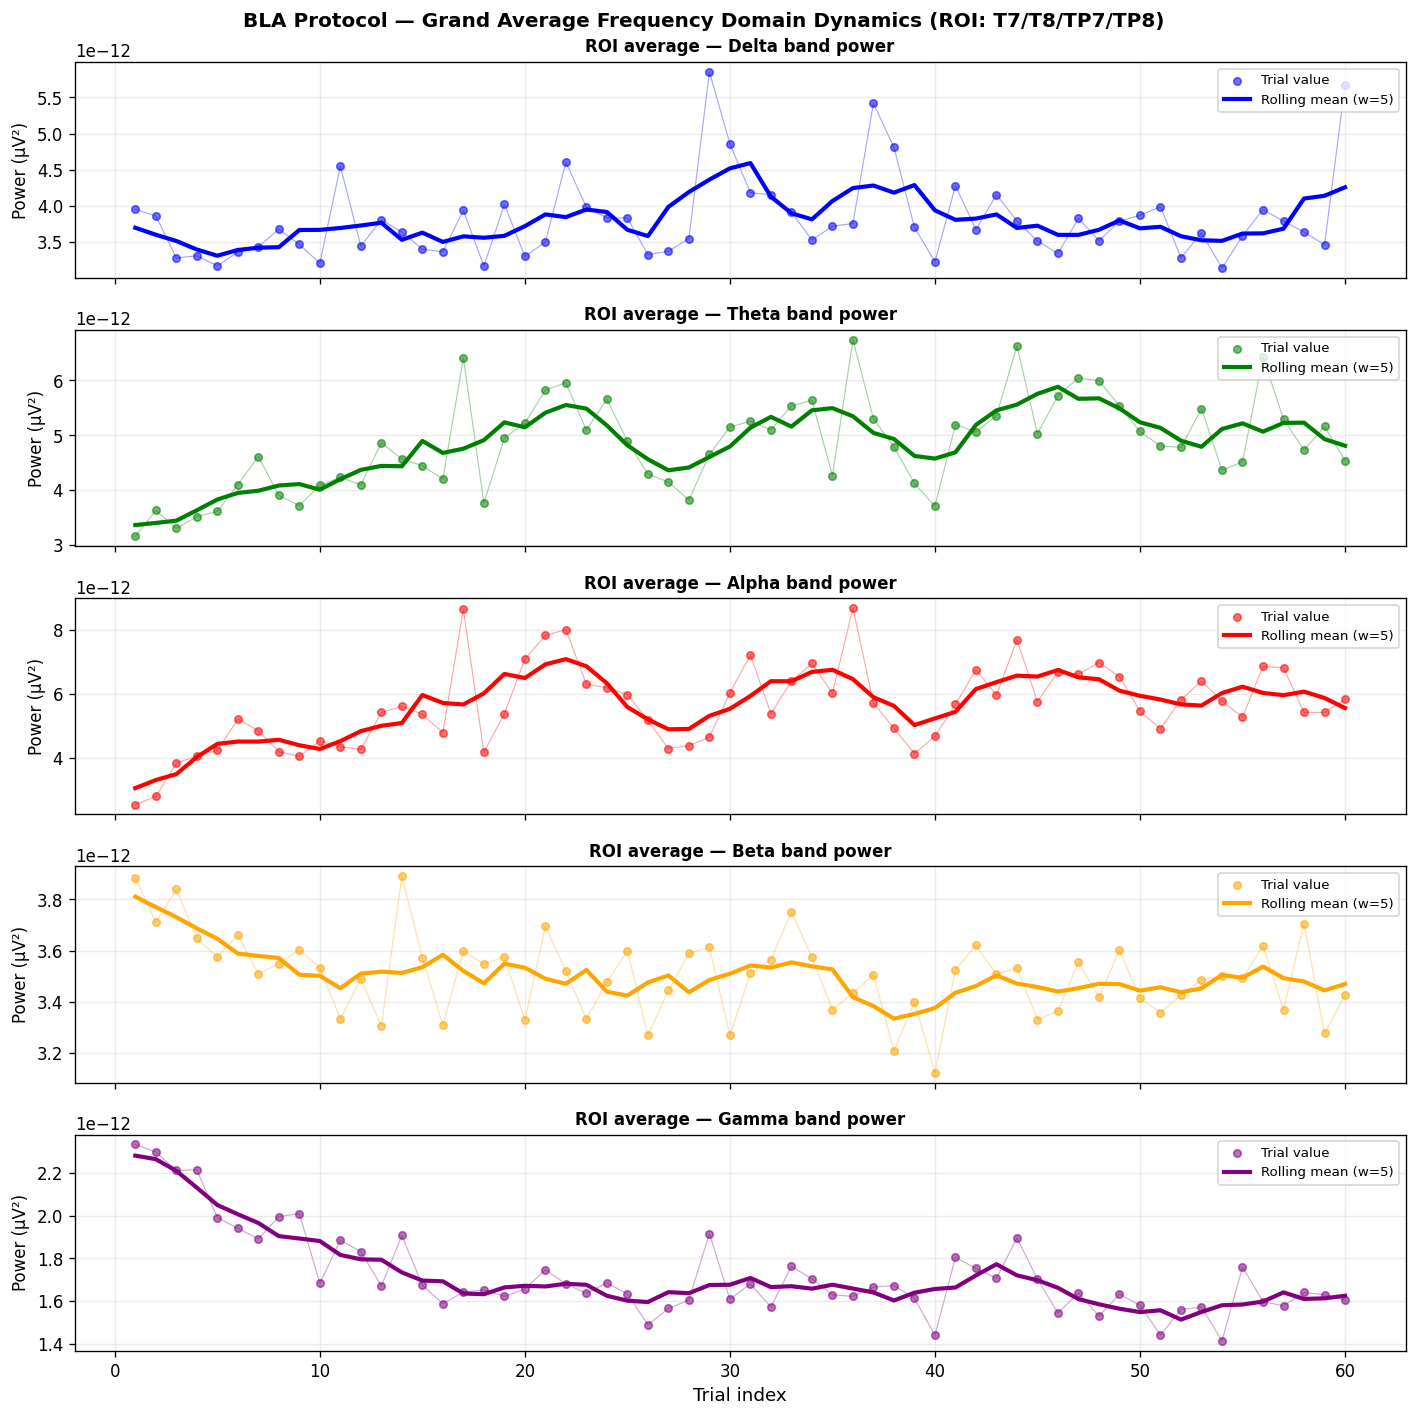

Figure saved: frequency_dynamics_BLA_grand_average.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Note: Grand average across all available BLA subject data files analyzed.


In [20]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# build grand-average power table across subjects
grand_power = {}
for band in bands:
    band_trials = []
    for subject_id in SUBJECTS:
        power_pivot = all_power_pivots[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        grand_power[band] = pd.concat(band_trials, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_power:
        values = grand_power[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Grand Average Frequency Domain Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: frequency_dynamics_BLA_grand_average.png")

print(f"Analysis completed for subjects: {SUBJECTS}")
print("Note: Grand average across all available BLA subject data files analyzed.")

In [13]:
# Compute relative power (percentage of total power) for frequency domain analysis
relative_power_dfs = {}
relative_power_pivots = {}

for subject_id in SUBJECTS:
    print(f"\n--- Computing Relative Power for Subject {subject_id} ---")

    power_pivot = all_power_pivots[subject_id]

    # Calculate total power across all bands for each trial
    total_power_per_trial = power_pivot.sum(axis=1)  # Sum across bands

    # Calculate relative power for each band
    relative_power = power_pivot.div(total_power_per_trial, axis=0) * 100  # Convert to percentage

    # Store results
    relative_power_dfs[subject_id] = relative_power.reset_index()
    relative_power_pivots[subject_id] = relative_power

    print(f"Subject {subject_id}: relative power computed for {len(relative_power)} trials")

# Display relative power results
subject_id = SUBJECTS[0]
print(f"\n--- Relative Power Results for Subject {subject_id} ---")
print("Relative power per band per trial (percentage of total power):")
relative_power_pivots[subject_id].head(10)


--- Computing Relative Power for Subject 2 ---
Subject 2: relative power computed for 60 trials

--- Computing Relative Power for Subject 3 ---
Subject 3: relative power computed for 60 trials

--- Computing Relative Power for Subject 5 ---
Subject 5: relative power computed for 60 trials

--- Computing Relative Power for Subject 6 ---
Subject 6: relative power computed for 60 trials

--- Computing Relative Power for Subject 7 ---
Subject 7: relative power computed for 60 trials

--- Computing Relative Power for Subject 8 ---
Subject 8: relative power computed for 60 trials

--- Computing Relative Power for Subject 9 ---
Subject 9: relative power computed for 60 trials

--- Computing Relative Power for Subject 10 ---
Subject 10: relative power computed for 60 trials

--- Computing Relative Power for Subject 11 ---
Subject 11: relative power computed for 60 trials

--- Computing Relative Power for Subject 12 ---
Subject 12: relative power computed for 60 trials

--- Computing Relative 

band,above_gamma,alpha,below_delta,beta,delta,gamma,theta
trial,,,,,,,
0,NaN,14.741465,NaN,26.774640,25.508426,12.985752,19.989717
1,NaN,11.466375,NaN,29.052152,22.565086,18.230317,18.686070
2,NaN,11.800105,NaN,24.774590,19.907710,17.329246,26.188348
3,NaN,10.870440,NaN,24.929588,23.454439,18.572848,22.172685
4,NaN,10.985789,NaN,28.098775,25.937991,14.713037,20.264409
5,NaN,15.460201,NaN,26.469031,23.051396,14.293158,20.726213
6,NaN,11.726466,NaN,26.935610,27.406393,14.722735,19.208796
7,NaN,10.716835,NaN,24.138646,27.303907,15.861832,21.978780
8,NaN,12.978170,NaN,29.159163,19.818785,17.492788,20.551095


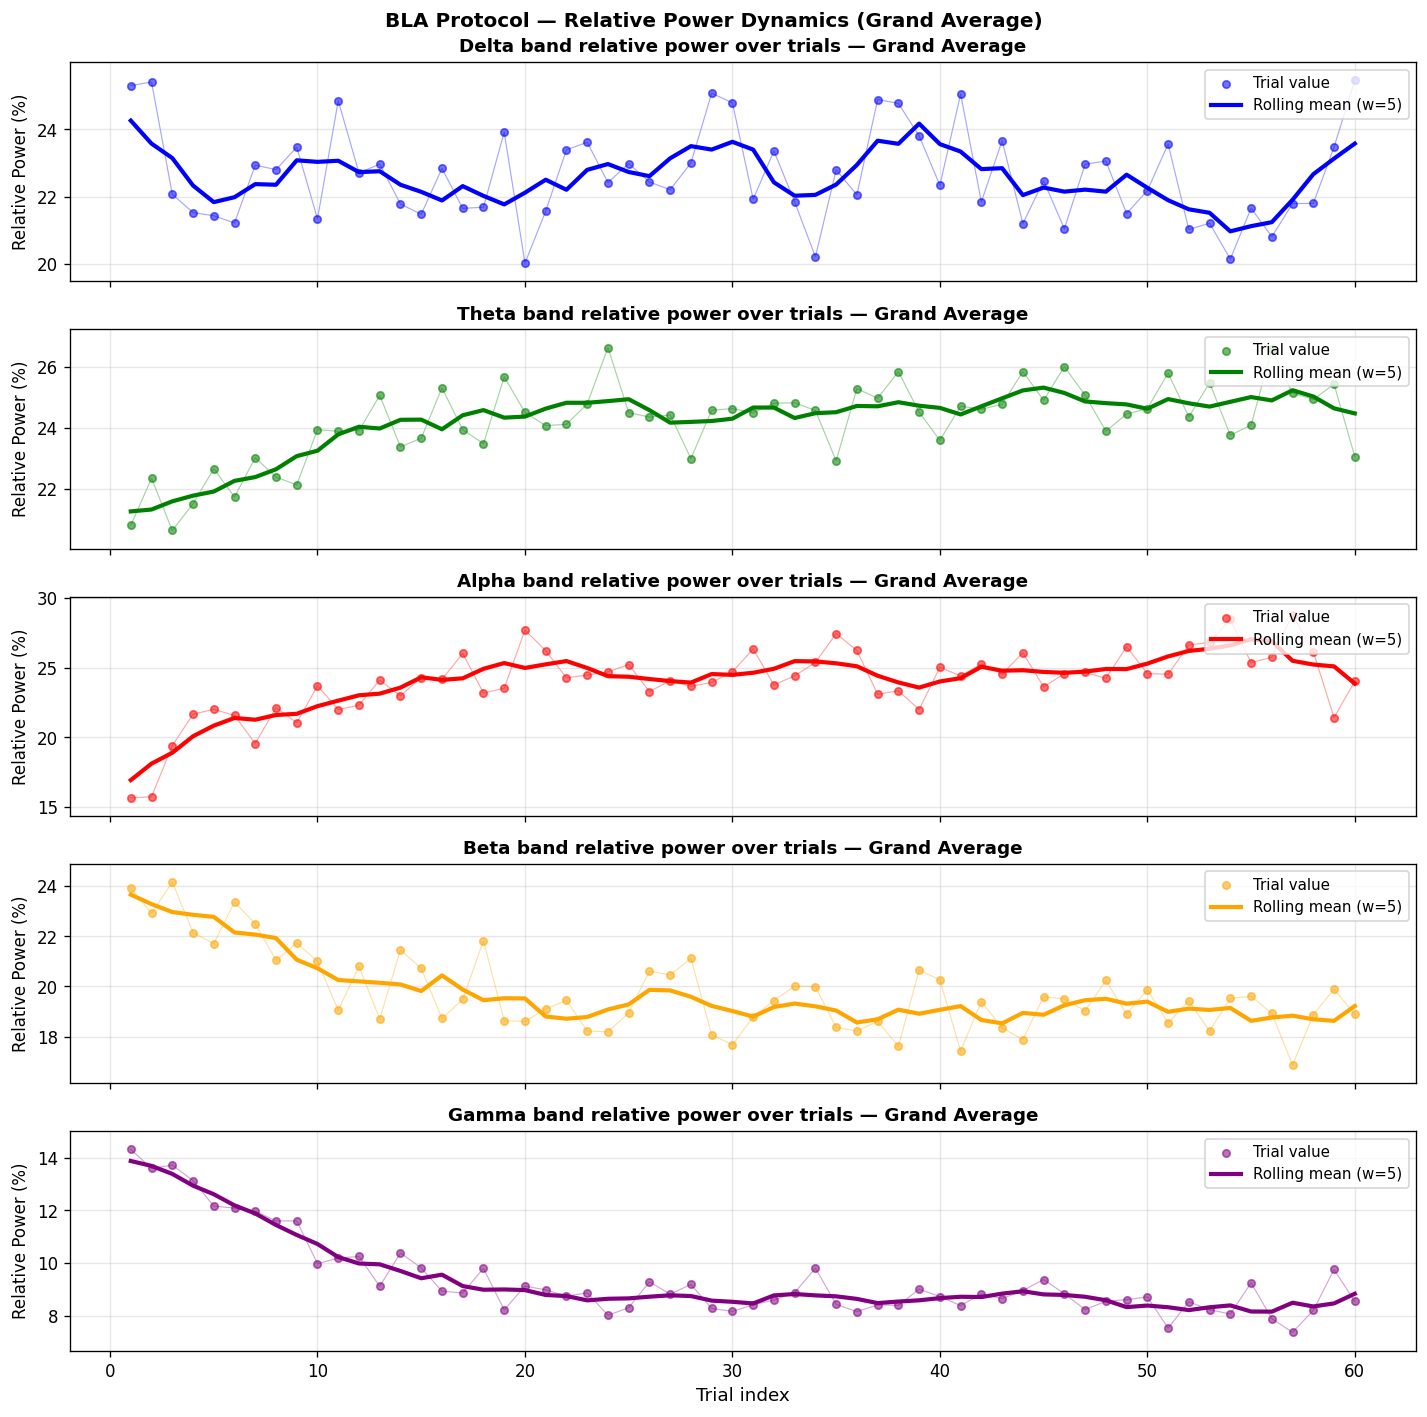

Figure saved: relative_power_dynamics_BLA_grand_average.png

Average relative power across all trials (Grand Average):
Delta: 22.6%
Theta: 24.2%
Alpha: 24.0%
Beta: 19.8%
Gamma: 9.4%


In [23]:
# Plot relative power dynamics over trials
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_relative_power = {}
for band in bands:
    band_trials = []
    for subject_id in SUBJECTS:
        relative_power_pivot = relative_power_pivots[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        grand_relative_power[band] = pd.concat(band_trials, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_relative_power:
        values = grand_relative_power[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        min_val = grand_relative_power[band].min()
        max_val = grand_relative_power[band].max()
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

        ax.set_ylabel('Relative Power (%)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band relative power over trials — Grand Average',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle('BLA Protocol — Relative Power Dynamics (Grand Average)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('relative_power_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: relative_power_dynamics_BLA_grand_average.png")

# Print average relative power across trials
print("\nAverage relative power across all trials (Grand Average):")
avg_relative_power = pd.DataFrame(grand_relative_power).mean()
for band in bands:
    if band in avg_relative_power.index:
        print(f"{band.capitalize()}: {avg_relative_power[band]:.1f}%")

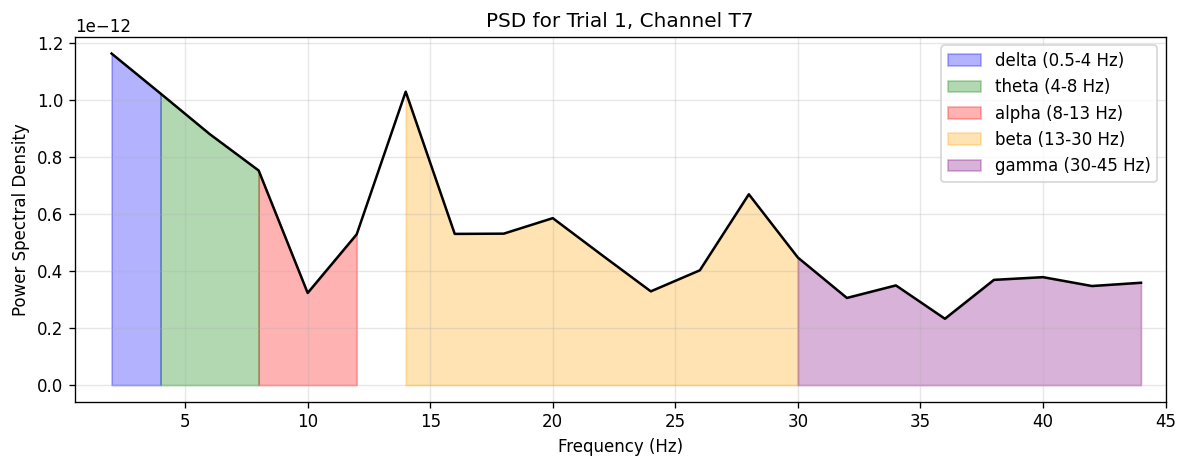

Figure saved: example_psd_BLA.png


In [49]:
# Example: Plot PSD for the first trial, first channel
trial = 0
channel = ch_names[0]
freqs, psd = psds_dict[(trial, channel)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, psd, color='black', linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density')
ax.set_title(f'PSD for Trial {trial+1}, Channel {channel}')
ax.grid(True, alpha=0.3)

# Shade frequency bands
band_colors = {'delta': 'blue', 'theta': 'green', 'alpha': 'red', 'beta': 'orange', 'gamma': 'purple'}
for band, (fmin, fmax) in FREQ_BANDS.items():
    if band in band_colors:
        mask = (freqs >= fmin) & (freqs <= fmax)
        ax.fill_between(freqs, 0, psd, where=mask, color=band_colors[band], alpha=0.3, label=f'{band} ({fmin}-{fmax} Hz)')

ax.legend()
ax.set_xlim(0.5, 45)
fig.tight_layout()
plt.savefig('example_psd_BLA.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: example_psd_BLA.png")

In [24]:
# Print PSD data for interpretation
trial = 0
channel = ch_names[0]
freqs, psd = psds_dict[(trial, channel)]

print(f"PSD for Trial {trial+1}, Channel {channel}")
print(f"Frequency range: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")
print(f"Number of frequency bins: {len(freqs)}")

# Find peak frequencies and powers in each band
from utils import FREQ_BANDS
for band, (fmin, fmax) in FREQ_BANDS.items():
    mask = (freqs >= fmin) & (freqs <= fmax)
    if mask.any():
        band_freqs = freqs[mask]
        band_psd = psd[mask]
        peak_idx = np.argmax(band_psd)
        peak_freq = band_freqs[peak_idx]
        peak_power = band_psd[peak_idx]
        mean_power = np.mean(band_psd)
        print(f"{band.capitalize()} band ({fmin}-{fmax} Hz): peak at {peak_freq:.1f} Hz ({peak_power:.2e} µV²), mean power {mean_power:.2e} µV²")

# Overall statistics
print(f"\nOverall PSD statistics:")
print(f"Total power (0.5-45 Hz): {np.sum(psd):.2e} µV²")
print(f"Mean power: {np.mean(psd):.2e} µV²")
print(f"Max power: {np.max(psd):.2e} µV² at {freqs[np.argmax(psd)]:.1f} Hz")

NameError: name 'ch_names' is not defined

In [25]:
# Count total trials for subject 5 across all conditions
import mne
from pathlib import Path

conditions = ['BLA', 'BLT', 'P1', 'P2', 'P3']
subject_id = 5

total_trials = 0
print("Trials per condition for Subject 5:")
print("-" * 40)

for condition in conditions:
    file_name = f"binepochs filtered ICArej {condition}AvgBOS{subject_id}.set"
    file_path = Path('dataset') / file_name

    if file_path.exists():
        epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

        # Count meaningful trials (excluding "no auditory")
        # Based on the pattern in utils.py, even indices are auditory trials
        meaningful_trials = sum(1 for i in range(len(epochs)) if i % 2 == 0)
        print(f"{condition}: {meaningful_trials} trials")
        total_trials += meaningful_trials
    else:
        print(f"{condition}: file not found")

print("-" * 40)
print(f"Total trials for Subject 5: {total_trials}")

Trials per condition for Subject 5:
----------------------------------------
BLA: 60 trials
BLT: 60 trials


/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_68885/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_68885/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_68885/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


P1: 60 trials
P2: 60 trials
P3: 60 trials
----------------------------------------
Total trials for Subject 5: 300


/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_68885/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_68885/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 7. Time-Frequency Domain Analysis

Analyze the time-frequency dynamics of BLA trials to understand how oscillatory activity evolves over time within each trial. This complements the frequency-domain analysis by showing when specific frequency bands are active during the post-stimulus period.

Time-frequency analysis reveals:
- Event-related spectral perturbations (ERSP)
- When oscillatory activity increases/decreases relative to stimulus onset
- Dynamic changes in brain rhythms during learning

**Method**: Continuous Wavelet Transform using Morlet wavelets
**Frequency bands**: Same as frequency domain (delta, theta, alpha, beta, gamma)
**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (all available BLA data)

In [3]:
# Import time-frequency functions
import mne
from mne.time_frequency import tfr_morlet

# Define parameters for time-frequency analysis
n_cycles = 2.0  # Number of cycles in Morlet wavelet
freqs = np.logspace(np.log10(1), np.log10(45), 20)  # Log-spaced frequencies from 1-45 Hz

print(f"Time-frequency analysis parameters:")
print(f"Frequencies: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz ({len(freqs)} points)")
print(f"Wavelet cycles: {n_cycles}")

# Define subjects (all available BLA subjects)
SUBJECTS_TF = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
CONDITION = "BLA"
CHANNELS = "BLA"

Time-frequency analysis parameters:
Frequencies: 1.0 - 45.0 Hz (20 points)
Wavelet cycles: 2.0


In [4]:
# Compute time-frequency representations for each subject
tf_power_dfs = {}
tf_power_pivots = {}

for subject_id in SUBJECTS_TF:
    print(f"\n--- Computing Time-Frequency for Subject {subject_id} ---")

    # Load data (reuse from frequency analysis if available, otherwise reload)
    try:
        epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)
    except:
        print(f"Reloading data for subject {subject_id}")
        epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)

    # Get baseline-corrected data
    data = epochs.get_data() * 1e6  # Convert to µV

    # Apply baseline correction (same as before)
    baseline_mask = (epochs.times >= -0.200) & (epochs.times <= 0.000)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    data_bc = data - baseline_mean

    n_trials, n_channels, n_times = data_bc.shape
    ch_names = epochs.ch_names

    print(f"Data shape: {data_bc.shape} (trials × channels × times)")

    # Compute TFR for each channel (this may take time)
    tfr_data = []
    for ch_idx, ch in enumerate(ch_names):
        print(f"Computing TFR for channel {ch}...")

        # Use only post-stimulus data for efficiency (0-400ms)
        post_stim_mask = epochs.times >= 0
        data_post = data_bc[:, ch_idx, post_stim_mask]
        times_post = epochs.times[post_stim_mask]

        # Compute TFR using Morlet wavelets
        # tfr_morlet expects (n_epochs, n_channels, n_times)
        tfr = tfr_morlet(epochs.copy().pick_channels([ch]), freqs, n_cycles=n_cycles,
                        average=False, return_itc=False, verbose=False)

        # Get power data (magnitude squared)
        power = tfr.data ** 2  # (n_trials, n_channels, n_freqs, n_times)

        # Average across channels (should be 1 channel)
        power_avg = power.mean(axis=1)  # (n_trials, n_freqs, n_times)

        tfr_data.append(power_avg)

    # Average across channels for ROI
    roi_power = np.mean(tfr_data, axis=0)  # (n_trials, n_freqs, n_times)

    # Extract power in frequency bands over time
    band_power_over_time = {}
    for band, (fmin, fmax) in FREQ_BANDS.items():
        # Find frequency indices for this band
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        if freq_mask.any():
            # Average power across frequencies in band, for each trial and time point
            band_power = roi_power[:, freq_mask, :].mean(axis=1)  # (n_trials, n_times)
            band_power_over_time[band] = band_power

    # Create DataFrame with time-frequency features
    tf_features = []
    for trial in range(n_trials):
        for time_idx, time_val in enumerate(times_post):
            row = {'trial': trial + 1, 'time_ms': time_val * 1000}
            for band in FREQ_BANDS.keys():
                if band in band_power_over_time:
                    row[f'{band}_power'] = band_power_over_time[band][trial, time_idx]
            tf_features.append(row)

    tf_df = pd.DataFrame(tf_features)

    # Create pivot table: trials × time × bands
    tf_pivot = {}
    for band in FREQ_BANDS.keys():
        if f'{band}_power' in tf_df.columns:
            pivot = tf_df.pivot(index='trial', columns='time_ms', values=f'{band}_power')
            tf_pivot[band] = pivot

    # Store results
    tf_power_dfs[subject_id] = tf_df
    tf_power_pivots[subject_id] = tf_pivot

    print(f"Subject {subject_id}: {len(tf_df)} time-frequency measurements computed")

# Display results for subject 5
subject_id = 5
print(f"\n--- Time-Frequency Results for Subject {subject_id} ---")
print("Time-frequency DataFrame (first 10 rows):")
tf_power_dfs[subject_id].head(10)

print(f"\nPower over time for delta band (first 5 trials, first 10 time points):")
tf_power_pivots[subject_id]['delta'].iloc[:5, :10]


--- Computing Time-Frequency for Subject 2 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel T7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  


Computing TFR for channel T8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 2: 92160 time-frequency measurements computed

--- Computing Time-Frequency for Subject 3 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel T7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy functio

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  


Computing TFR for channel T8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 3: 92160 time-frequency measurements computed

--- Computing Time-Frequency for Subject 5 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel T7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy functio

...

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  


Computing TFR for channel T8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 16: 92160 time-frequency measurements computed

--- Computing Time-Frequency for Subject 17 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel T7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy funct

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  


Computing TFR for channel T8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP7...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel TP8...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 17: 92160 time-frequency measurements computed

--- Time-Frequency Results for Subject 5 ---
Time-frequency DataFrame (first 10 rows):

Power over time for delta band (first 5 trials, first 10 time points):


time_ms,0.000000,1.953125,3.906250,5.859375,7.812500,9.765625,11.718750,13.671875,15.625000,17.578125
trial,,,,,,,,,,
1,1.045994e-18,1.060276e-18,1.074533e-18,1.088759e-18,1.102950e-18,1.117100e-18,1.131204e-18,1.145257e-18,1.159254e-18,1.173192e-18
2,1.770617e-19,1.776464e-19,1.781876e-19,1.786883e-19,1.791513e-19,1.795796e-19,1.799759e-19,1.803431e-19,1.806840e-19,1.810011e-19
3,4.293210e-20,4.395173e-20,4.498514e-20,4.603129e-20,4.708895e-20,4.815671e-20,4.923296e-20,5.031592e-20,5.140362e-20,5.249390e-20
4,6.156835e-20,6.367605e-20,6.585434e-20,6.810549e-20,7.043184e-20,7.283581e-20,7.531992e-20,7.788676e-20,8.053902e-20,8.327951e-20
5,1.489918e-19,1.508743e-19,1.526834e-19,1.544156e-19,1.560680e-19,1.576379e-19,1.591234e-19,1.605228e-19,1.618349e-19,1.630590e-19


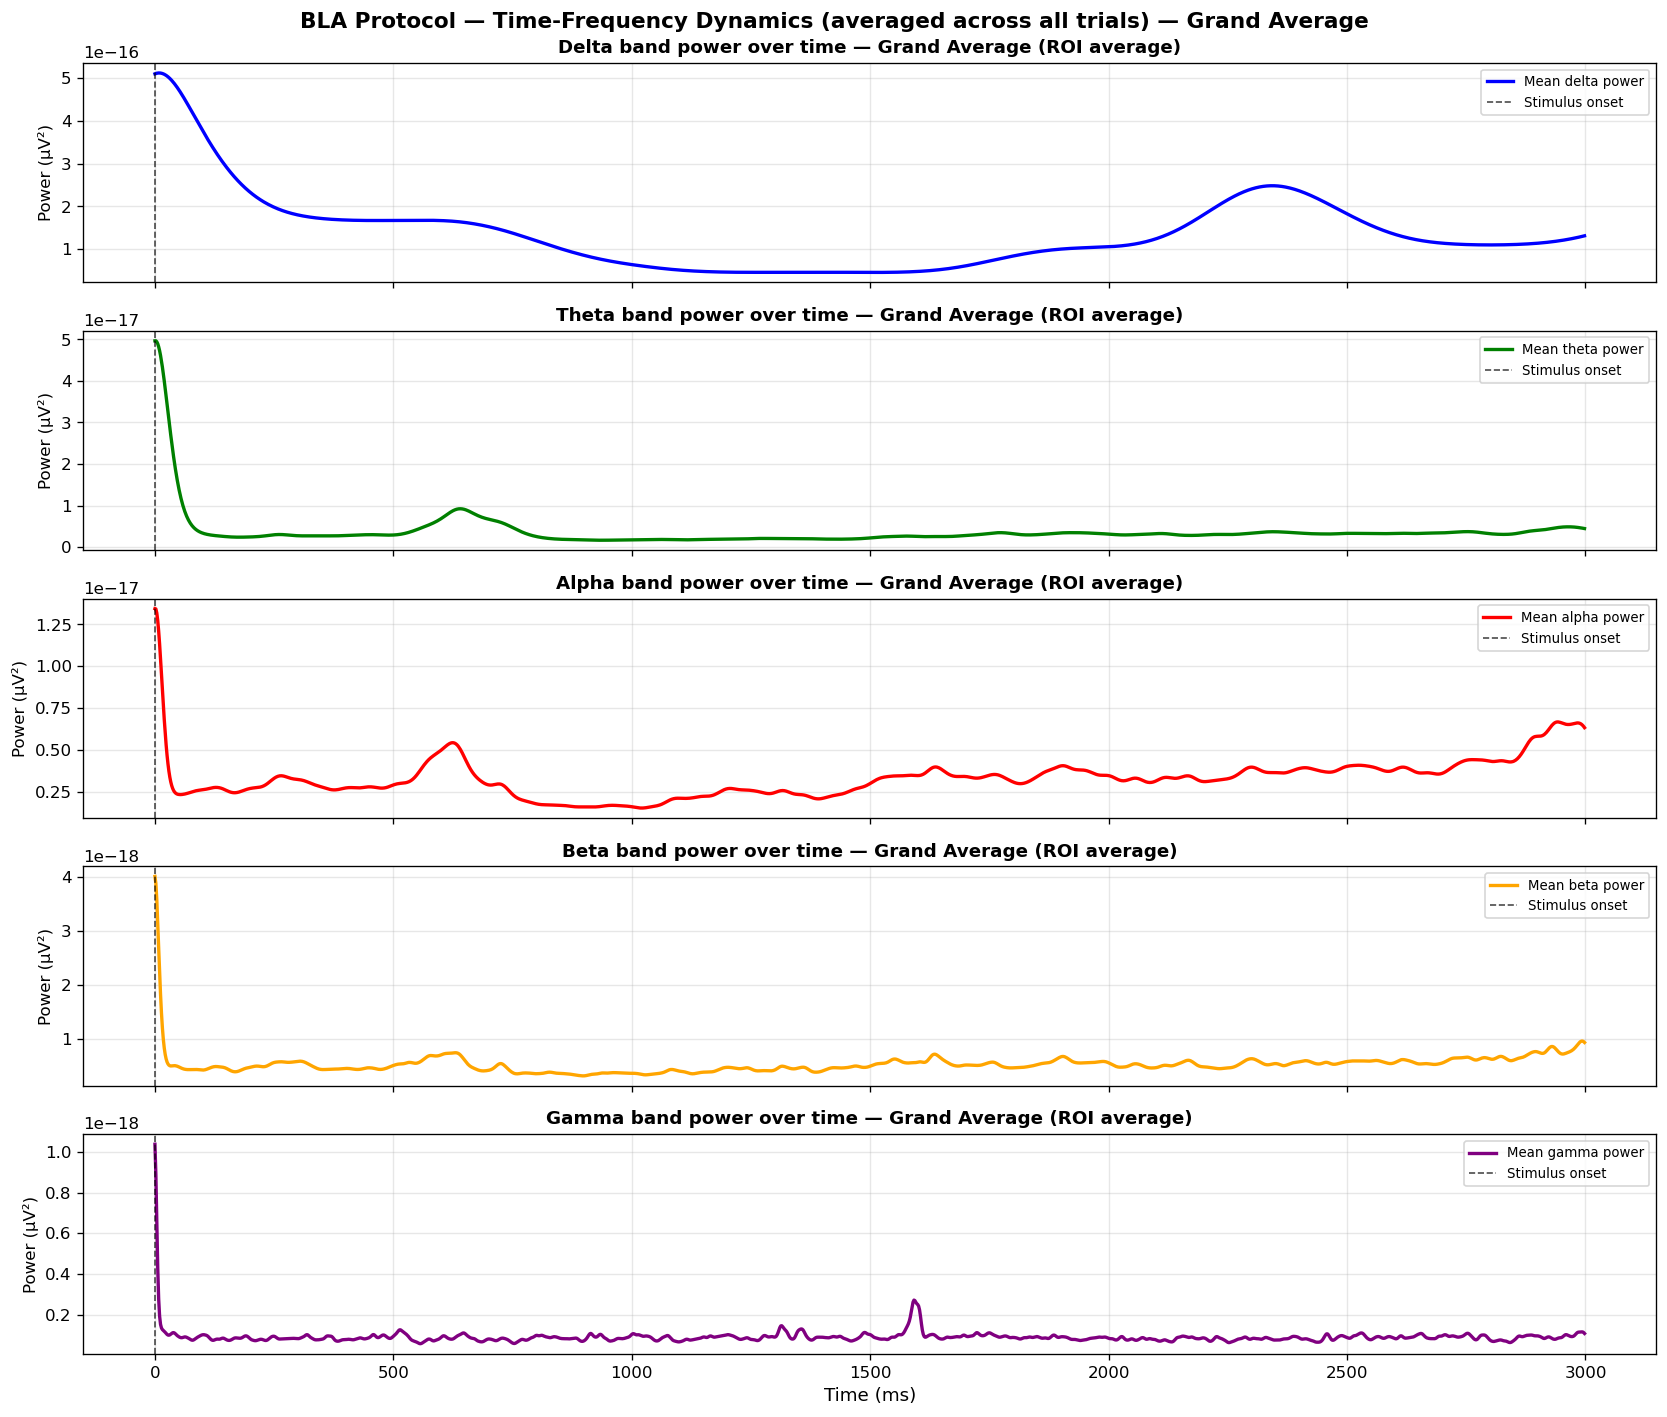

Figure saved: time_frequency_dynamics_BLA_grand_average.png


In [5]:
# Plot time-frequency power dynamics over trials (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_power = {}
for band in bands:
    band_subject_means = []
    for subject_id in SUBJECTS_TF:
        if subject_id in tf_power_pivots:
            tf_pivot = tf_power_pivots[subject_id]
            if band in tf_pivot:
                pivot_data = tf_pivot[band]

                # mean over trials for this subject
                subject_mean = pivot_data.mean(axis=0)
                band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        grand_tf_power[band] = pd.concat(band_subject_means, axis=1)

# Get time points for plotting
time_points = tf_power_pivots[SUBJECTS_TF[0]]['delta'].columns.values  # time in ms

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    if band in grand_tf_power:
        pivot_data = grand_tf_power[band]

        # Plot grand mean power over time across all subjects
        mean_power = pivot_data.mean(axis=1)

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        ax.set_ylabel('Power (µV²)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band power over time — Grand Average (ROI average)',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle('BLA Protocol — Time-Frequency Dynamics (averaged across all trials) — Grand Average',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: time_frequency_dynamics_BLA_grand_average.png")

In [31]:
# Compute relative power for time-frequency domain analysis
tf_relative_power_dfs = {}
tf_relative_power_pivots = {}

for subject_id in SUBJECTS_TF:
    print(f"\n--- Computing Relative Time-Frequency Power for Subject {subject_id} ---")

    tf_pivot = tf_power_pivots[subject_id]

    # For each time point, calculate relative power across bands
    relative_tf_pivot = {}
    for band in FREQ_BANDS.keys():
        if band in tf_pivot:  # Check if band exists in tf_pivot
            # Get power for this band across all time points and trials
            band_pivot = tf_pivot[band]

            # Calculate total power across all bands at each time point for each trial
            # We need to sum power across bands at each time point
            time_points = band_pivot.columns
            total_power_at_time = pd.DataFrame(index=band_pivot.index, columns=time_points)

            for time_point in time_points:
                total_at_time = 0
                for b in FREQ_BANDS.keys():
                    if b in tf_pivot:  # Check if band exists
                        total_at_time += tf_pivot[b][time_point]
                total_power_at_time[time_point] = total_at_time

            # Calculate relative power: band_power / total_power * 100
            relative_power = (band_pivot.div(total_power_at_time, axis=0)) * 100
            relative_tf_pivot[band] = relative_power

    # Store results
    tf_relative_power_dfs[subject_id] = relative_tf_pivot
    tf_relative_power_pivots[subject_id] = relative_tf_pivot

    print(f"Subject {subject_id}: relative time-frequency power computed")

# Display results for subject 5
subject_id = 5
print(f"\n--- Relative Time-Frequency Results for Subject {subject_id} ---")
print("Available bands:", list(tf_relative_power_pivots[subject_id].keys()))
print("Relative power for delta band (first 5 trials, first 5 time points):")
if 'delta' in tf_relative_power_pivots[subject_id]:
    print(tf_relative_power_pivots[subject_id]['delta'].iloc[:5, :5])
else:
    print("Delta band not found")


--- Computing Relative Time-Frequency Power for Subject 2 ---
Subject 2: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 3 ---
Subject 3: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 5 ---
Subject 5: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 6 ---
Subject 6: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 7 ---
Subject 7: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 8 ---
Subject 8: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 9 ---
Subject 9: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 10 ---
Subject 10: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 11 ---
Subject 11: relative time-freq

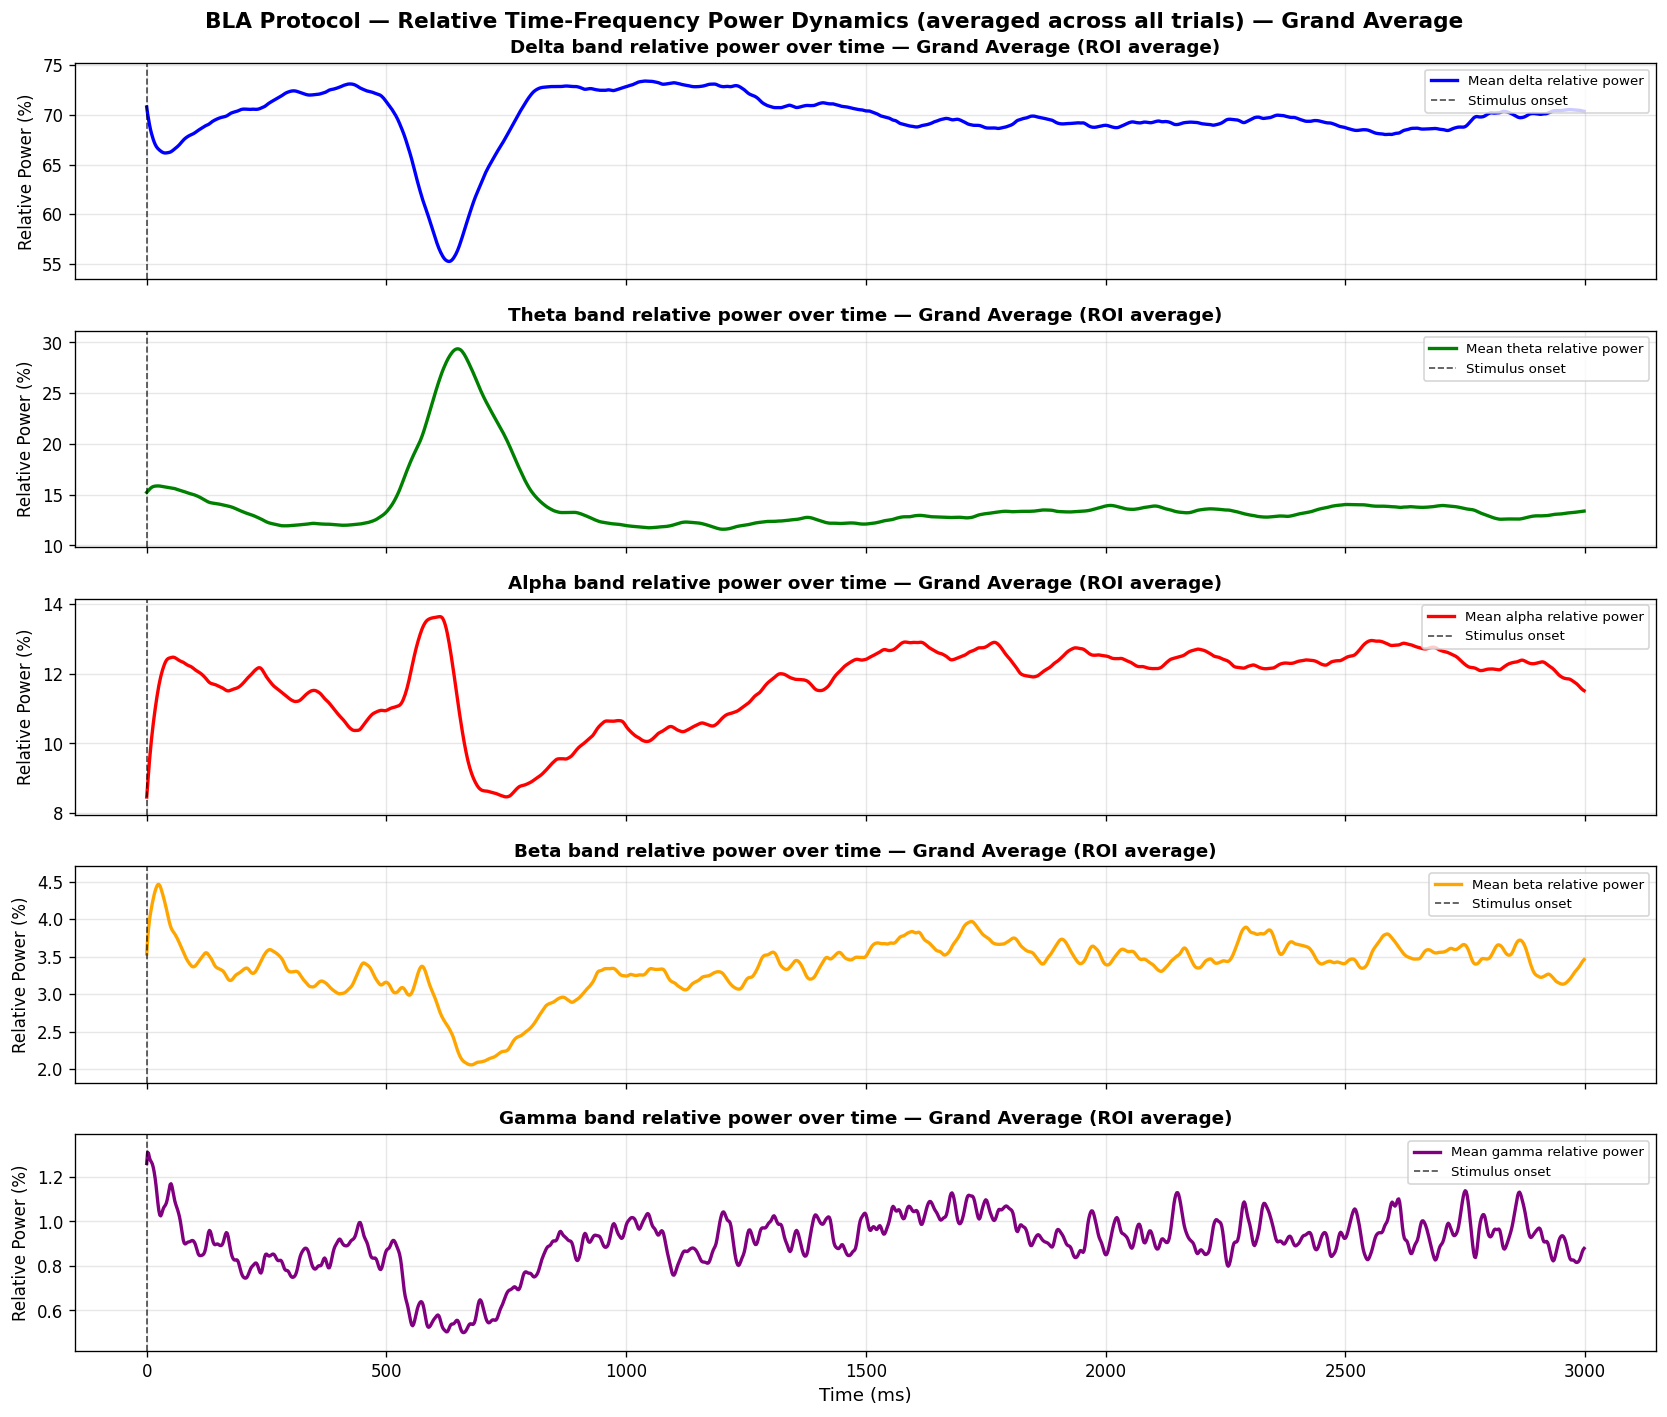

Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png

Average relative power across time (Grand Average):
Delta: 69.6%
Theta: 14.0%
Alpha: 11.7%
Beta: 3.4%
Gamma: 0.9%




In [33]:
# Plot relative time-frequency power dynamics over trials (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_relative_power = {}
for band in bands:
    band_subject_means = []
    for subject_id in SUBJECTS_TF:
        if subject_id in tf_relative_power_pivots:
            tf_relative_pivot = tf_relative_power_pivots[subject_id]
            if band in tf_relative_pivot:
                pivot_data = tf_relative_pivot[band]

                # mean over trials for this subject
                subject_mean = pivot_data.mean(axis=0)
                band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        grand_tf_relative_power[band] = pd.concat(band_subject_means, axis=1)

# Get time points for plotting
time_points = tf_relative_power_pivots[SUBJECTS_TF[0]]['delta'].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    if band in grand_tf_relative_power:
        pivot_data = grand_tf_relative_power[band]

        # Plot grand mean relative power over time across all subjects
        mean_power = pivot_data.mean(axis=1)

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        # Set y-axis to fit the data properly
        min_val = mean_power.min()
        max_val = mean_power.max()
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

        ax.set_ylabel('Relative Power (%)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band relative power over time — Grand Average (ROI average)',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle('BLA Protocol — Relative Time-Frequency Power Dynamics (averaged across all trials) — Grand Average',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('relative_time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png")

# Print average relative power across time for each band
print("\nAverage relative power across time (Grand Average):")
for band in bands:
    if band in grand_tf_relative_power:
        avg_relative_power = grand_tf_relative_power[band].mean().mean()
        print(f"{band.capitalize()}: {avg_relative_power:.1f}%")
print("\n" + "="*50 + "\n")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


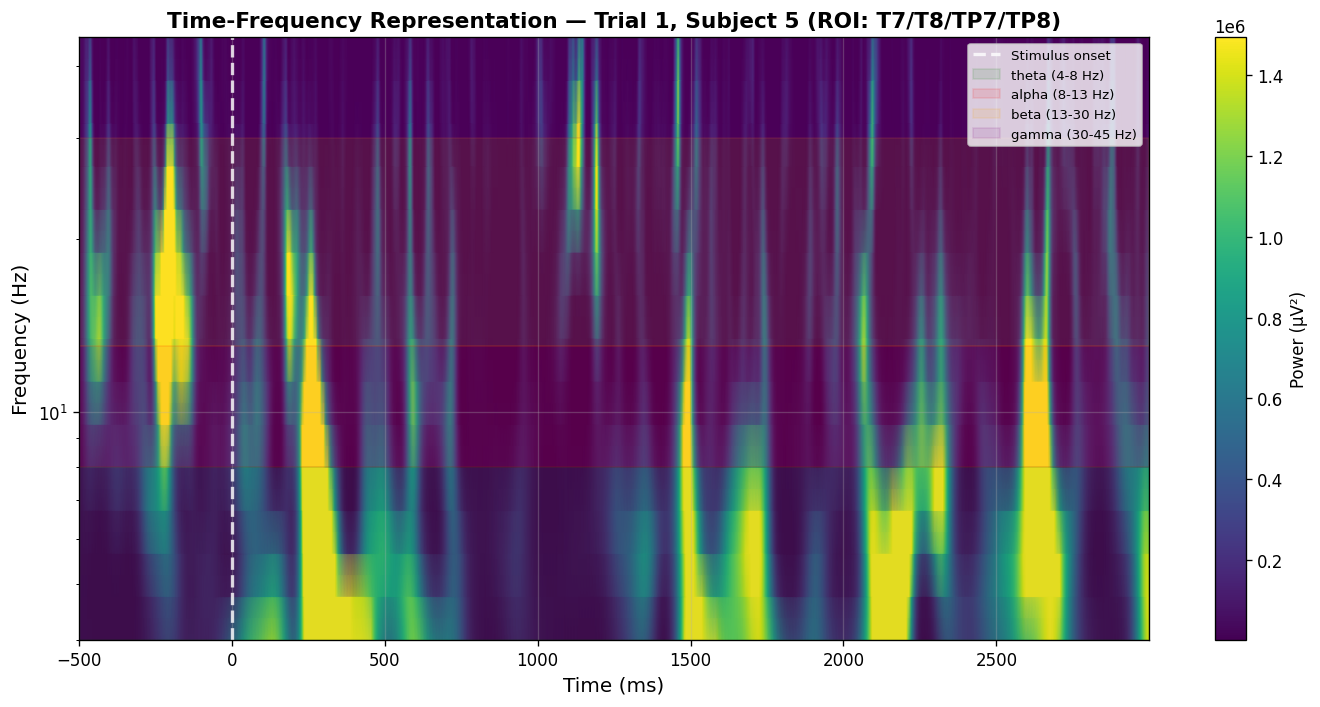

Figure saved: example_time_frequency_BLA.png

Time-frequency statistics for Trial 1:
Delta band: mean power 2.21e+06 µV², max power 4.89e+06 µV²
Theta band: mean power 1.53e+06 µV², max power 7.71e+06 µV²
Alpha band: mean power 8.82e+05 µV², max power 6.60e+06 µV²
Beta band: mean power 2.86e+05 µV², max power 2.77e+06 µV²
Gamma band: mean power 5.60e+04 µV², max power 6.40e+05 µV²


In [23]:
# Example: Plot time-frequency representation for the first trial, ROI average
trial = 0
subject_id = 5  # Example subject

# Load data for single trial TFR
epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)
data = epochs.get_data() * 1e6

# Baseline correction for all trials
baseline_mask = (epochs.times >= -0.200) & (epochs.times <= 0.000)
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
data_bc = data - baseline_mean

# Create single-trial epochs properly
info = epochs.info
single_trial_data = data_bc[trial:trial+1]  # Shape: (1, n_channels, n_times)
epochs_trial = mne.EpochsArray(single_trial_data, info, tmin=epochs.tmin, verbose=False)

# Use higher frequency range to avoid wavelet length issues
freqs_example = np.logspace(np.log10(4), np.log10(45), 15)  # 4-45 Hz

tfr = tfr_morlet(epochs_trial, freqs_example, n_cycles=n_cycles,
                average=False, return_itc=False, verbose=False)

# Average across channels
power = (tfr.data ** 2).mean(axis=1).squeeze()  # (n_freqs, n_times)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Create time-frequency plot
times_ms = tfr.times * 1000
mesh = ax.pcolormesh(times_ms, freqs_example, power,
                    shading='gouraud', cmap='viridis',
                    vmin=np.percentile(power, 5), vmax=np.percentile(power, 95))

ax.axvline(0, color='white', linestyle='--', linewidth=2, alpha=0.8, label='Stimulus onset')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Frequency (Hz)', fontsize=12)
ax.set_title(f'Time-Frequency Representation — Trial {trial+1}, Subject {subject_id} (ROI: T7/T8/TP7/TP8)',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Power (µV²)', fontsize=10)

# Shade frequency bands (adjusted for higher freq range)
band_colors = {'theta': 'green', 'alpha': 'red', 'beta': 'orange', 'gamma': 'purple'}
for band, (fmin, fmax) in FREQ_BANDS.items():
    if band in band_colors and fmax >= 4:  # Only show bands that overlap with our freq range
        plot_fmin = max(fmin, 4)
        plot_fmax = min(fmax, 45)
        ax.axhspan(plot_fmin, plot_fmax, alpha=0.1, color=band_colors[band],
                  label=f'{band} ({fmin}-{fmax} Hz)')

ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('example_time_frequency_BLA.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: example_time_frequency_BLA.png")

# Print some statistics
print(f"\nTime-frequency statistics for Trial {trial+1}:")
for band, (fmin, fmax) in FREQ_BANDS.items():
    if fmax >= 4:  # Only for bands in our frequency range
        freq_mask = (freqs_example >= max(fmin, 4)) & (freqs_example <= min(fmax, 45))
        time_mask = (times_ms >= 0) & (times_ms <= 400)  # Post-stimulus window
        if freq_mask.any():
            band_power = power[freq_mask, :][:, time_mask]
            mean_power = np.mean(band_power)
            max_power = np.max(band_power)
            print(f"{band.capitalize()} band: mean power {mean_power:.2e} µV², max power {max_power:.2e} µV²")

## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | 60 |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Time-frequency method | Continuous Wavelet Transform (Morlet wavelets) |
| Frequencies | 1-45 Hz (log-spaced, 20 points) |
| Wavelet cycles | 2.0 |
| Frequency bands | Delta (0.5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz), Beta (13-30 Hz), Gamma (30-45 Hz) |

**Key differences from frequency domain analysis:**
- **Frequency domain**: Shows average power in each frequency band across the entire trial
- **Time-frequency domain**: Shows how power in each frequency band changes over time within each trial

**Relative power analysis:**
- **Frequency domain**: Relative power shows the percentage contribution of each band to total power across trials
- **Time-frequency domain**: Relative power shows the percentage contribution of each band at each time point
- **Advantages**: Normalizes for individual differences in overall power levels, focuses on relative contributions

**Next steps:**
- Analyze other protocols (BLT, P1, P2, P3) for subject 5
- Compare relative power dynamics across protocols
- Look for event-related spectral perturbations (ERSP) that indicate learning-related changes

ValueError: No axis named 1 for object type Series

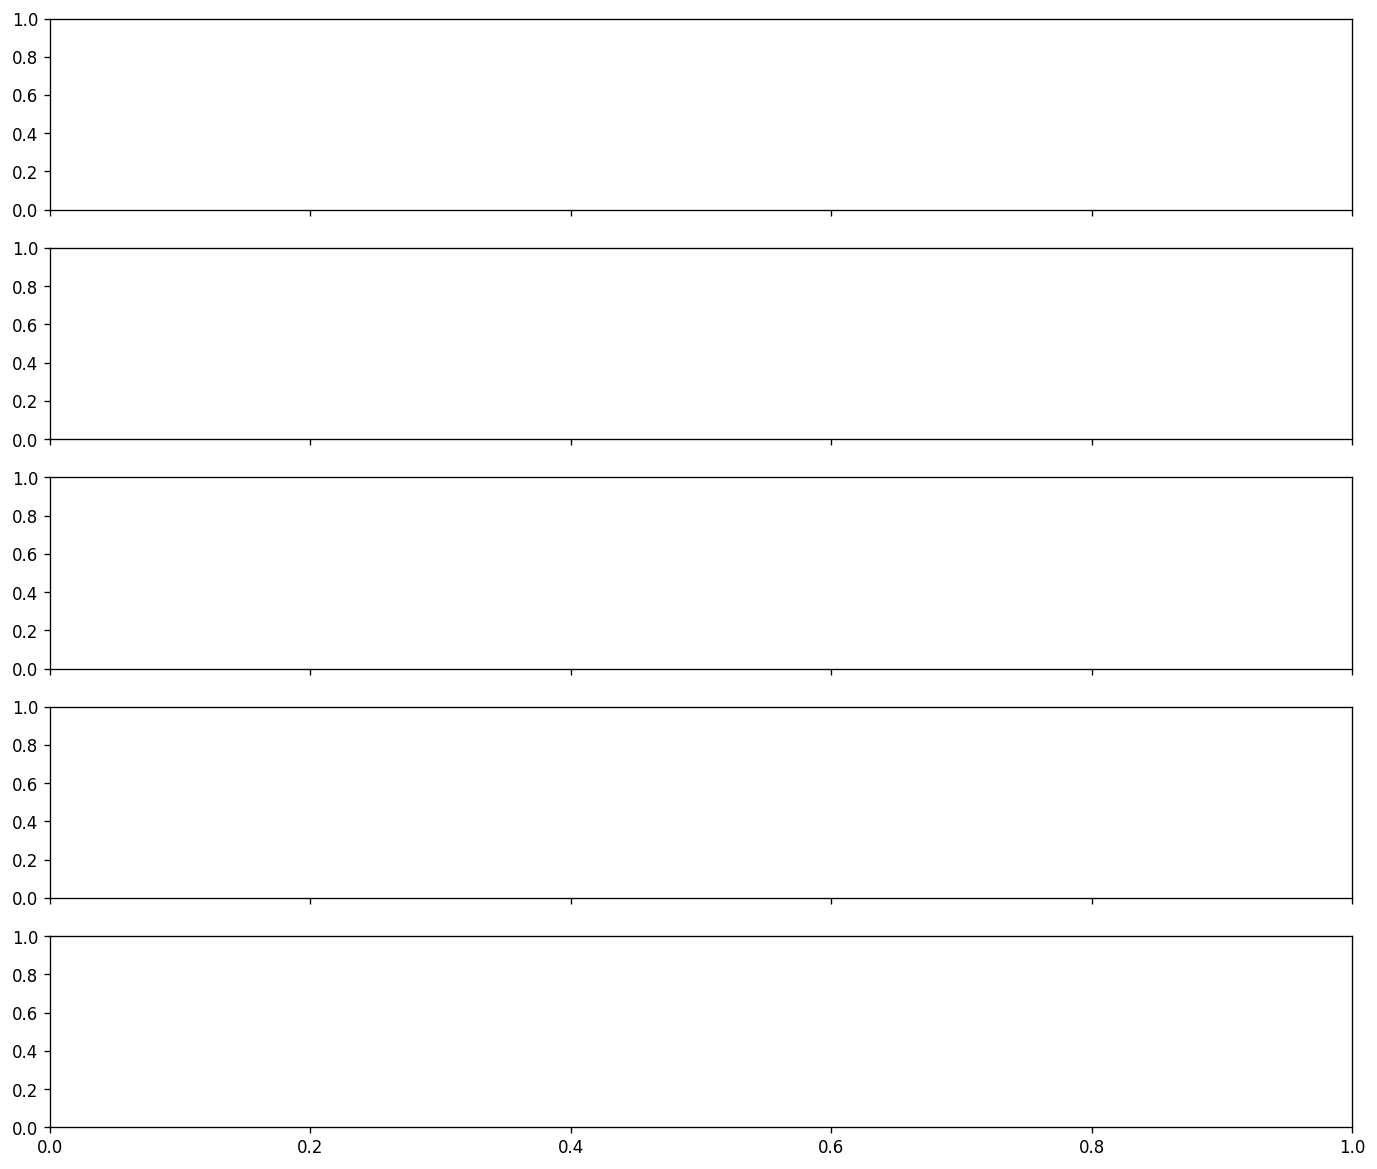

In [5]:
# Plot frequency power dynamics over trials for all subjects (individual plots)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

for subject_id in SUBJECTS:
    if subject_id in all_power_pivots:
        power_pivot = all_power_pivots[subject_id]

        # Get trial indices for plotting
        trial_idx = power_pivot.index.values

        fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

        for i, band in enumerate(bands):
            ax = axes[i]
            if band in power_pivot.columns.get_level_values(0):
                band_data = power_pivot[band]

                # Plot mean power over trials
                mean_power = band_data.mean(axis=1)
                std_power = band_data.std(axis=1)

                ax.plot(trial_idx, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')
                ax.fill_between(trial_idx, mean_power - std_power, mean_power + std_power,
                               color=colors[i], alpha=0.3, label='±1 SD')

                ax.set_ylabel('Power (µV²)', fontsize=10)
                ax.set_title(f'{band.capitalize()} band power over trials — Subject {subject_id} (ROI average)',
                            fontsize=11, fontweight='bold')
                ax.grid(True, alpha=0.3)
                ax.legend(loc='upper right', fontsize=8)

        axes[-1].set_xlabel('Trial index', fontsize=11)
        fig.suptitle(f'BLA Protocol — Frequency Domain Dynamics (averaged across time) — Subject {subject_id}',
                     fontsize=13, fontweight='bold')
        fig.tight_layout()
        plt.savefig(f'frequency_dynamics_BLA_subject_{subject_id}.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f"Figure saved: frequency_dynamics_BLA_subject_{subject_id}.png")